In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [98]:
df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\smartcart_customers.csv")

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# Data Preprocessing

In [100]:
# Fill the NaN values 
df['Income']  = df['Income'].fillna(df['Income'].median())

# Feature Engineering

In [101]:
#AGE 
df['Age'] = 2026 - df['Year_Birth']

In [102]:
# convert to datatime columns and get refreses date

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst=True)


referrnce_date = df['Dt_Customer'].max()


df['Customer_Tenure_Days'] = (referrnce_date  - df['Dt_Customer']).dt.days


In [103]:
# Spending combing the columns

df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts']+df['MntGoldProds'] 

In [104]:
# Childreen 

df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [105]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [106]:
# Educations 
df['Education'] = df['Education'].replace({
    'Basic':"Undergraduate",'2n Cycle':'Undergraduate',
    "Graduation":'Graduate',
    'Master':'Postgraduate',"PhD": "Postgraduate"
})

In [107]:
#Marrital Status 
df['Living_With'] = df['Marital_Status'].replace({
    'Single':'Alone',"Divorced":"Alone","Widow":'Alone',
    "Absurd":"Alone",'YOLO': 'Alone',
    'Married':'Partner','Together':'Partner'
})

# Drop Columns

In [108]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [109]:
cols = ['Year_Birth','Marital_Status', "Kidhome", 'Teenhome', 'Dt_Customer',"ID"]
speding_cols = ['MntWines',"MntMeatProducts",'MntFruits','MntFishProducts','MntSweetProducts','MntGoldProds']

cols_drop = cols + speding_cols

df_cleaned = df.drop(columns=cols_drop)

In [110]:
df_cleaned.shape

(2240, 15)

# Outlier 

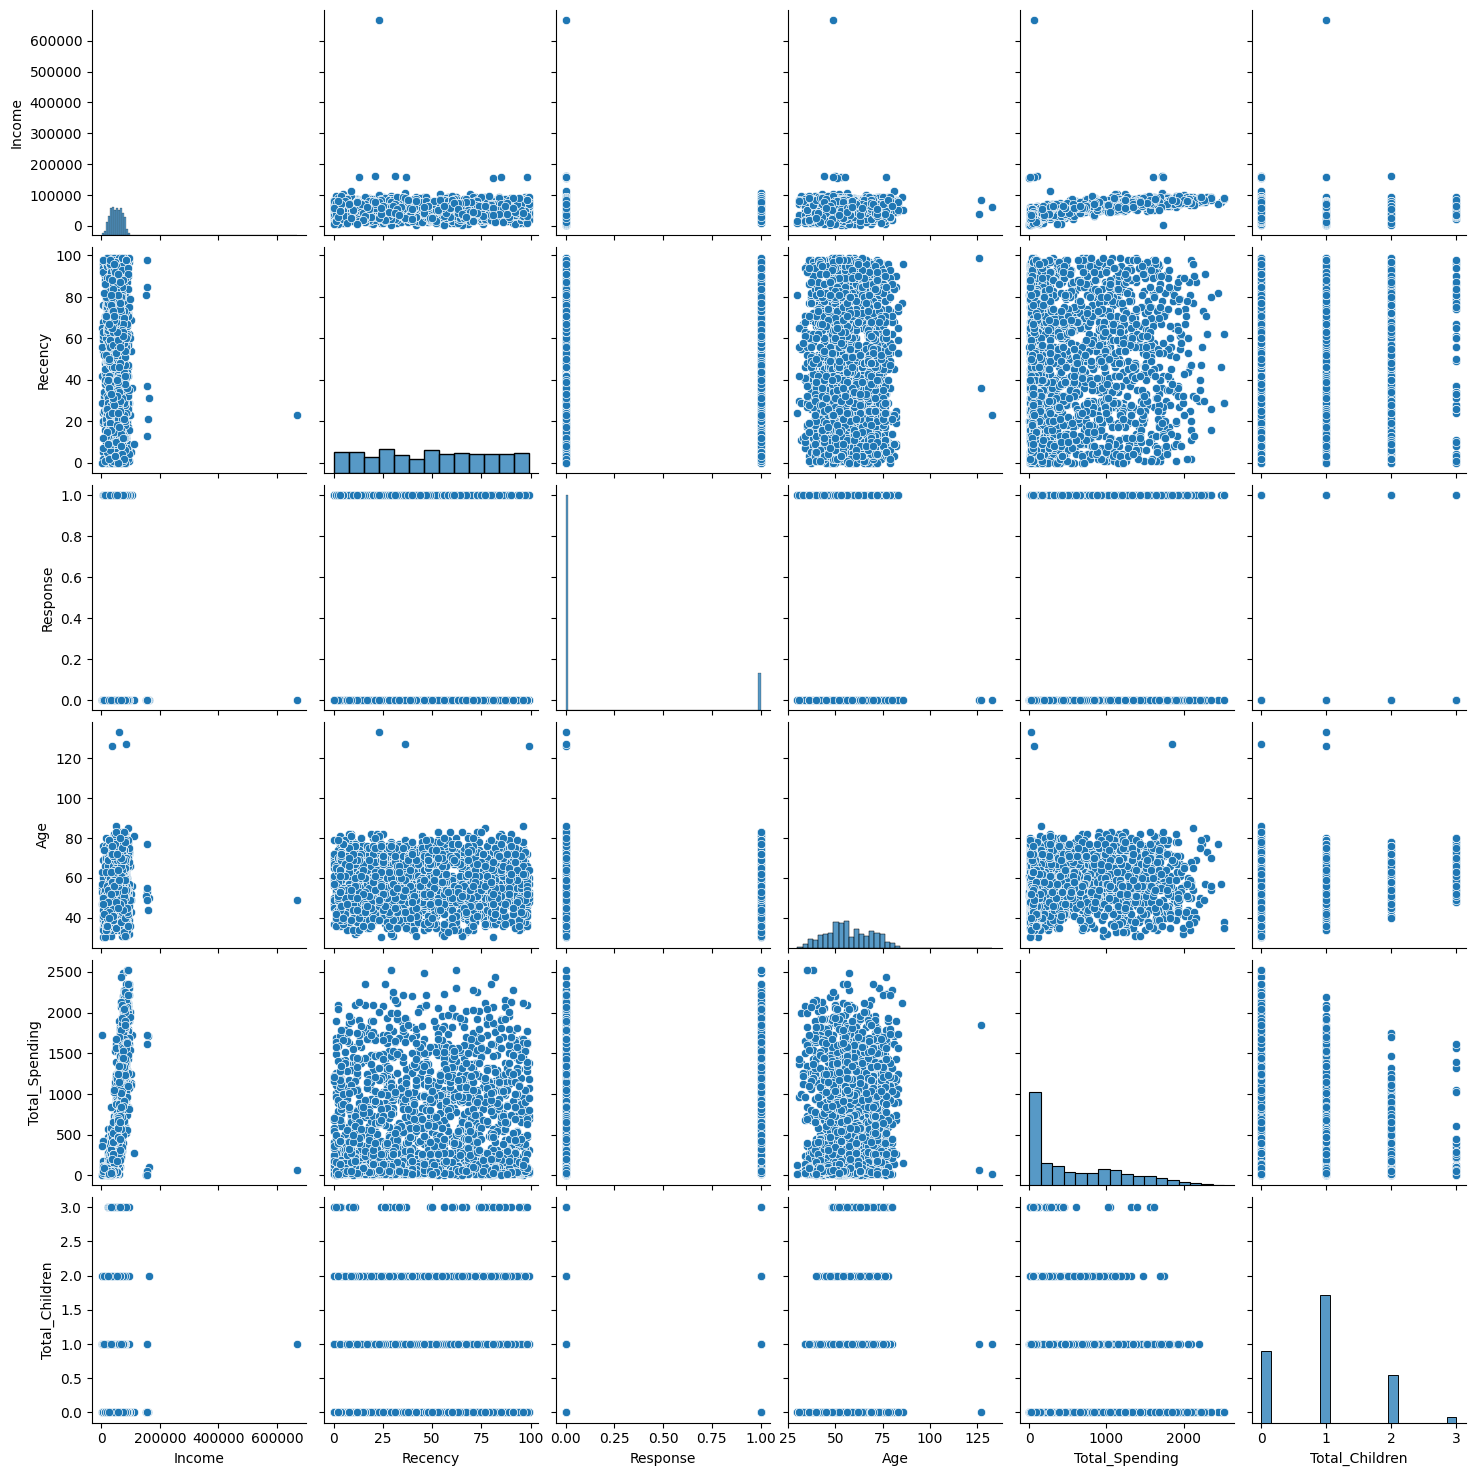

In [78]:
cols = ['Income', 'Recency', 'Response','Age','Total_Spending','Total_Children']


sns.pairplot(df_cleaned[cols])

In [120]:
# REmove the Outliers
print("data size eith Outliers ",len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned['Age'] < 90)]
df_cleaned = df_cleaned[ (df_cleaned['Income'] < 600_000)]

print("data Size without Outliers ",len(df_cleaned))

data size eith Outliers  2240
data Size without Outliers  2236


# After Cleaned The Outliers 

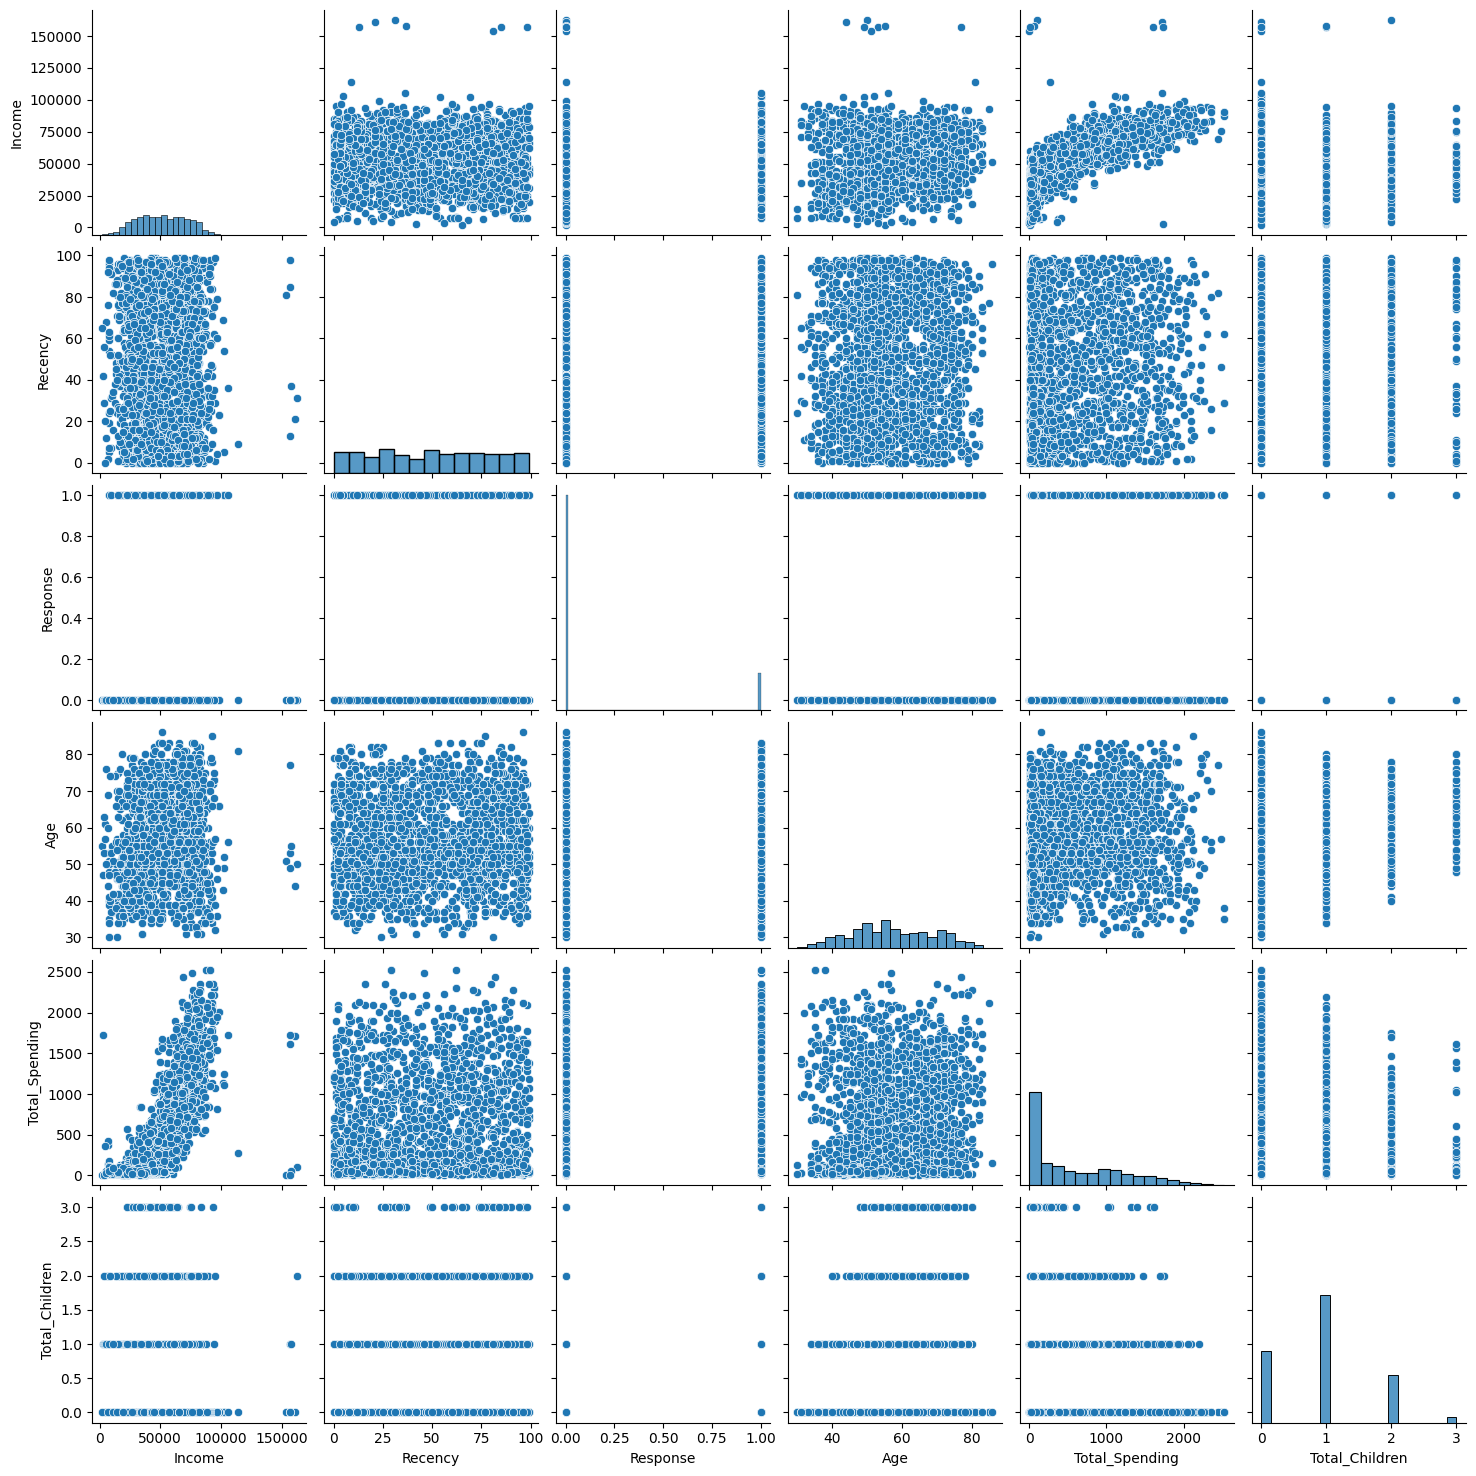

In [80]:
sns.pairplot(df_cleaned[cols])

# Heatmap

<Axes: >

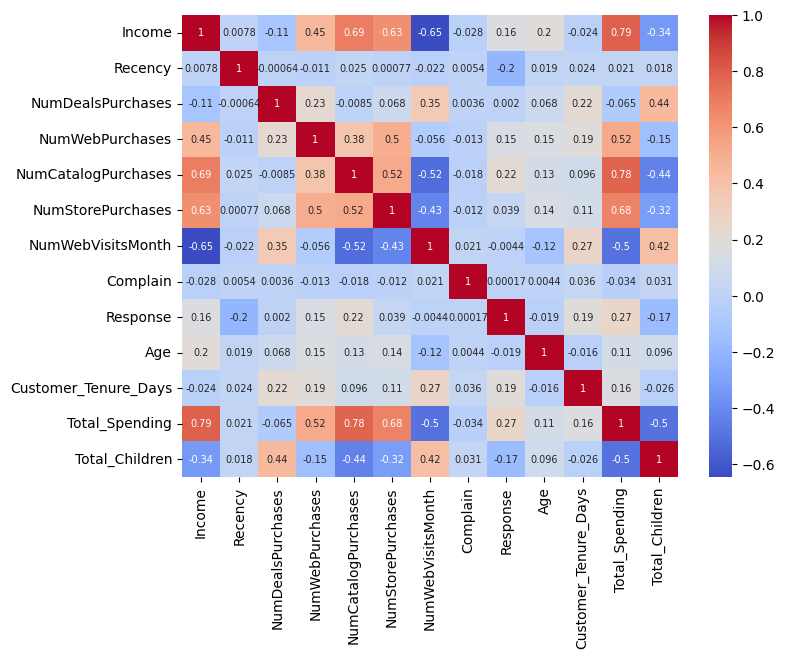

In [81]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws={'size': 7},
    cmap = "coolwarm"
)

In [111]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding the Data

In [121]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


tranformer = ColumnTransformer(
    transformers=[
        
        ('tnf12', OneHotEncoder(handle_unknown='ignore'),['Education',  'Living_With'])
    ],
    remainder='passthrough'
)



df_cleaned_Encode  = pd.DataFrame(
    tranformer.fit_transform(df_cleaned),
    columns=tranformer.get_feature_names_out()
)

# Scaling the data

In [123]:
from sklearn.preprocessing import StandardScaler


In [124]:
X = df_cleaned_Encode

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [179]:
X.head()

,tnf12__Education_Graduate,tnf12__Education_Postgraduate,tnf12__Education_Undergraduate,tnf12__Living_With_Alone,tnf12__Living_With_Partner,remainder__Income,remainder__Recency,remainder__NumDealsPurchases,remainder__NumWebPurchases,remainder__NumCatalogPurchases,remainder__NumStorePurchases,remainder__NumWebVisitsMonth,remainder__Complain,remainder__Response,remainder__Age,remainder__Customer_Tenure_Days,remainder__Total_Spending,remainder__Total_Children
0,1.0,0.0,0.0,1.0,0.0,58138.0,58.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663.0,1617.0,0.0
1,1.0,0.0,0.0,1.0,0.0,46344.0,38.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113.0,27.0,2.0
2,1.0,0.0,0.0,0.0,1.0,71613.0,26.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312.0,776.0,0.0
3,1.0,0.0,0.0,0.0,1.0,26646.0,26.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139.0,53.0,1.0
4,0.0,1.0,0.0,0.0,1.0,58293.0,94.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161.0,422.0,1.0


In [128]:
X_scaled.shape

(2236, 18)

# Visualize the Data

In [133]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

x_pca =pca.fit_transform(X_scaled)

Text(0.5, 0.92, 'PCA FOR 3D ')

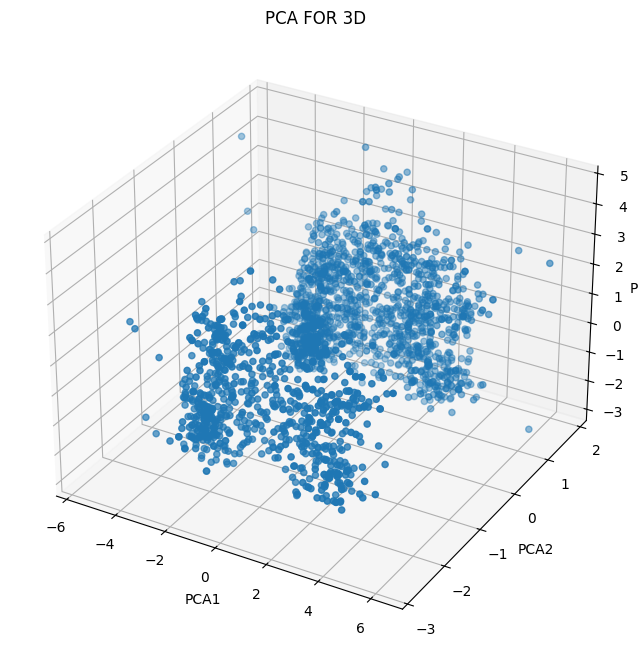

In [138]:
# plot
fig = plt.figure(figsize =(8,8))
ax = fig.add_subplot(111 , projection= '3d')

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title("PCA FOR 3D ")

In [134]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze the K values

In [141]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [143]:
wcss = []
for k in range(1,11):
    kmenas = KMeans(n_clusters=k, random_state=42)
    kmenas.fit_predict(x_pca)
    wcss.append(kmenas.inertia_)

In [144]:
knee = KneeLocator(range(1,11), wcss , curve='convex' , direction = 'decreasing')
optimal_k = knee.elbow


In [145]:
optimal_k

np.int64(4)

Text(0.5, 1.0, 'Eblow values')

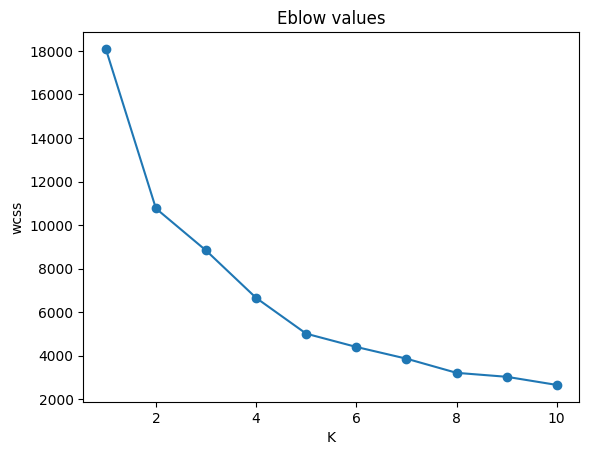

In [147]:
# plot

plt.plot(range(1,11), wcss , marker = 'o')
plt.xlabel('K')
plt.ylabel('wcss')
plt.title("Eblow values")

In [149]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmens = KMeans(n_clusters=k, random_state=42)
    label =  kmens.fit_predict(x_pca)
    score = silhouette_score(x_pca , label)
    scores.append(score)
    

Text(0.5, 1.0, 'silhouette_score for KMeans')

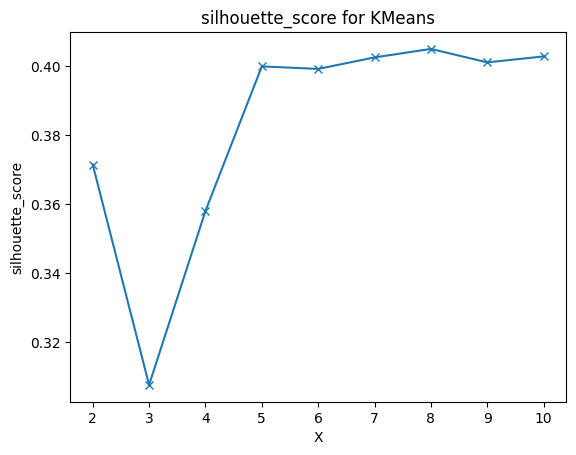

In [150]:
# plot
plt.plot(range(2,11),scores, marker ="x")
plt.xlabel("X")
plt.ylabel('silhouette_score')
plt.title('silhouette_score for KMeans')

Text(0, 0.5, 'ss')

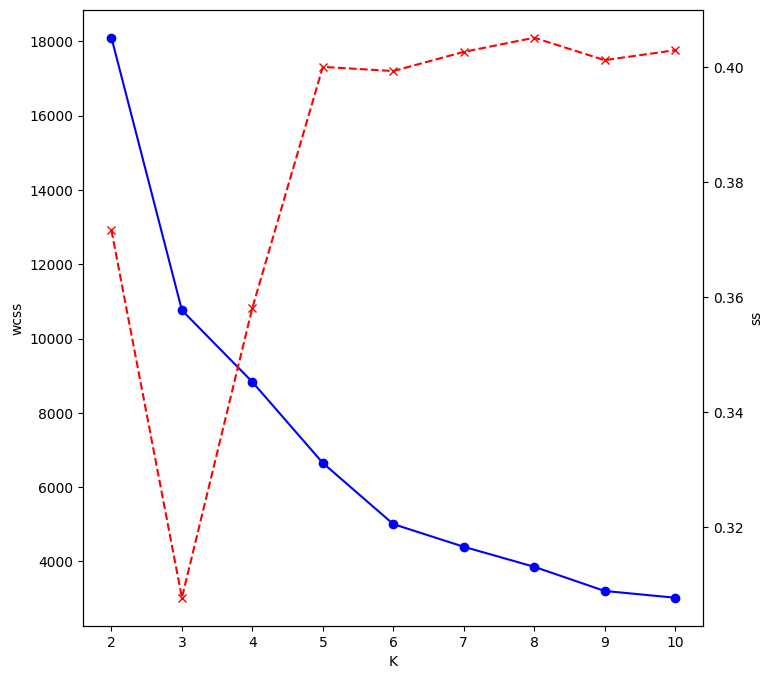

In [155]:
# Combined Plot

k_range = range(2,11)

fig , ax1 = plt.subplots(figsize = (8,8))

ax1.plot(k_range , wcss[:len(k_range)],marker = "o", color = 'blue')
ax1.set_xlabel('K')
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)],marker = 'x', color = 'red', linestyle = '--')
ax2.set_ylabel('ss')

# Clustering algorithumns

In [156]:
# K =Means 
kmenas = KMeans(n_clusters=4 , random_state=42)
labels_kmens = kmenas.fit_predict(x_pca)

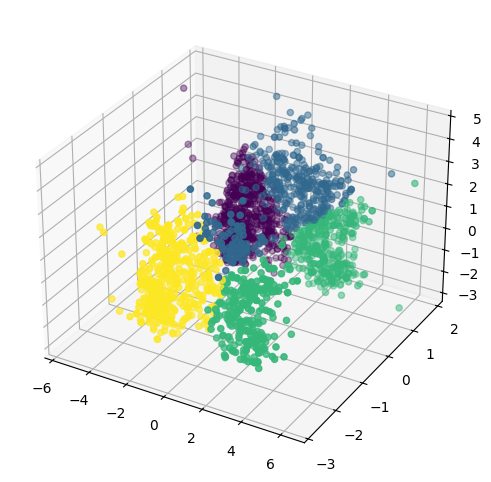

In [159]:
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection = '3d')

ax.scatter(x_pca[:,0],x_pca[:,1] , x_pca[:,2], c= labels_kmens)




In [161]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage='ward')

label_agg  = agg_clf.fit_predict(x_pca)

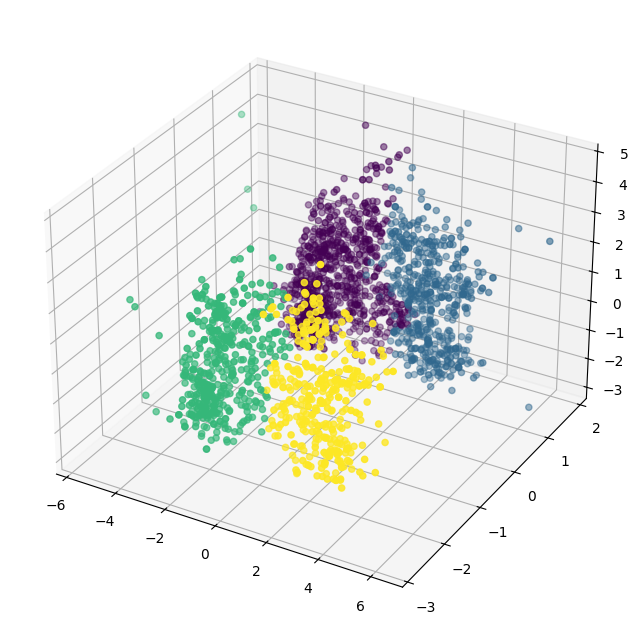

In [162]:
fig  = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c = label_agg)

# Charcterization of Cluster


In [173]:
df_cleaned = df_cleaned.drop(columns='labels', axis= 1)
df_cleaned['cluster'] = label_agg

In [174]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With', 'cluster'],
      dtype='object')

<Axes: xlabel='cluster', ylabel='count'>

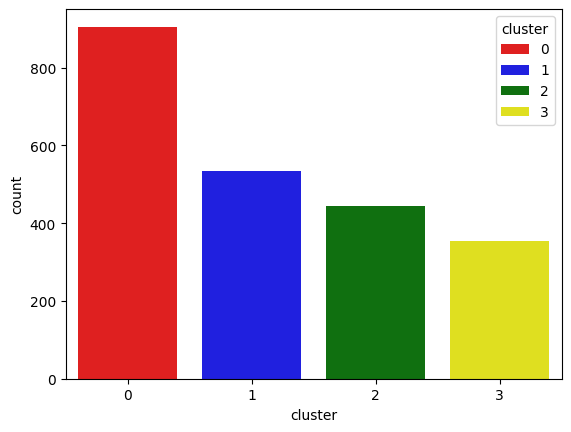

In [175]:
pal = ['red', 'blue', 'green', 'yellow']

sns.countplot(x = df_cleaned['cluster'], palette = pal, hue = df_cleaned['cluster'])

<Axes: xlabel='Total_Spending', ylabel='Income'>

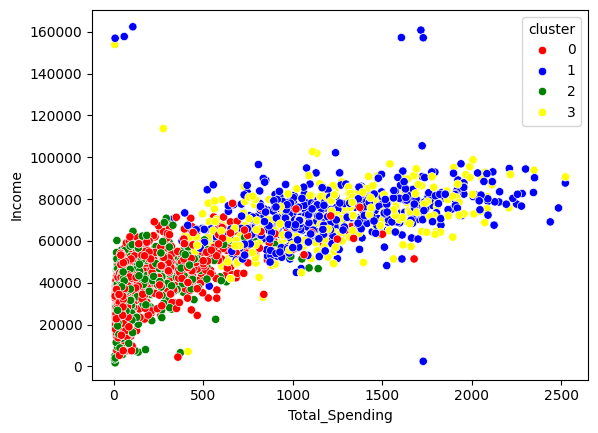

In [177]:
sns.scatterplot(x = df_cleaned['Total_Spending'], y = df_cleaned['Income'],hue= df_cleaned['cluster'],palette= pal)

In [180]:
X['cluster'] = label_agg

In [183]:
X.shape

(2236, 19)

In [181]:
cluster_summary = X.groupby('cluster').mean()
print(cluster_summary)

         tnf12__Education_Graduate  tnf12__Education_Postgraduate  \
cluster                                                             
0                         0.514917                       0.338122   
1                         0.471910                       0.455056   
2                         0.488739                       0.378378   
3                         0.541076                       0.390935   

         tnf12__Education_Undergraduate  tnf12__Living_With_Alone  \
cluster                                                             
0                              0.146961                  0.000000   
1                              0.073034                  0.000000   
2                              0.132883                  0.993243   
3                              0.067989                  1.000000   

         tnf12__Living_With_Partner  remainder__Income  remainder__Recency  \
cluster                                                                      
0             

In [184]:
cluster_summary

,tnf12__Education_Graduate,tnf12__Education_Postgraduate,tnf12__Education_Undergraduate,tnf12__Living_With_Alone,tnf12__Living_With_Partner,remainder__Income,remainder__Recency,remainder__NumDealsPurchases,remainder__NumWebPurchases,remainder__NumCatalogPurchases,remainder__NumStorePurchases,remainder__NumWebVisitsMonth,remainder__Complain,remainder__Response,remainder__Age,remainder__Customer_Tenure_Days,remainder__Total_Spending,remainder__Total_Children
cluster,,,,,,,,,,,,,,,,,,
0,0.514917,0.338122,0.146961,0.000000,1.000000,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094
1,0.471910,0.455056,0.073034,0.000000,1.000000,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236
2,0.488739,0.378378,0.132883,0.993243,0.006757,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523
3,0.541076,0.390935,0.067989,1.000000,0.000000,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756
